# Phase 2 — Ranking: do situational features beat naive baselines?

**Driving question (EVAL_DESIGN §2):** does information available *before* a gameweek rank players'
returns better than a naive within-position baseline — and do signals *combined* beat the best
single signal?

**What this stage must prove:** (a) situational features beat the Phase-0 incumbent (`base_season`)
at within-position ranking; (b) a regularized combination beats **both** the incumbent **and** the
best single signal (closes assumption **A-F1**); (c) *which* signals actually survive a fair penalty.

**Honest scope:** this is *ranking* (within-position Spearman), **not** a decision (that is Phase 5),
and **not** a points total (that is Phase 3). Population: `minutes > 0`, DGW-excluded, expanding
walk-forward. Metric is rank, so `+0.03` is a real but modest lift, not an accuracy claim.

## Setup

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from model.eval.walkforward import POSITIONS
from model.forecast.component_forecast import walk_forward_component_points, xg_vs_goals_forecast_skill
from model.forecast.signal_combination import walk_forward_signal_combination, selection_stability

try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f'Rebuilding mart ({type(err).__name__})...'); run_pipeline(force=True); loaded = load_mart()
mart = loaded.mart

comp = walk_forward_component_points(mart)          # Phase 2.1
xg_goals = xg_vs_goals_forecast_skill(mart)          # design check: lagged xG vs goals
combo = walk_forward_signal_combination(mart)       # Phase 2.2 (tuned elastic net)
sel = selection_stability(mart)                     # A-F1 receipt
print(f'Study range: GW 1 - {loaded.data_cutoff_gw} | minutes > 0 | DGW excluded | within-position Spearman')

## (a) Phase 2.1 — do component features beat the identity-only baseline?

Fit each point-driver (goals/assists/CS/GK-saves) one GW ahead from lagged features, compose to
E[points], score within position vs `base_season` (the expanding prior mean).

model,base_season (incumbent),component model
position,,
GK,0.0408,0.0391
DEF,0.1853,0.2165
MID,0.3359,0.3552
FWD,0.3490,0.3368


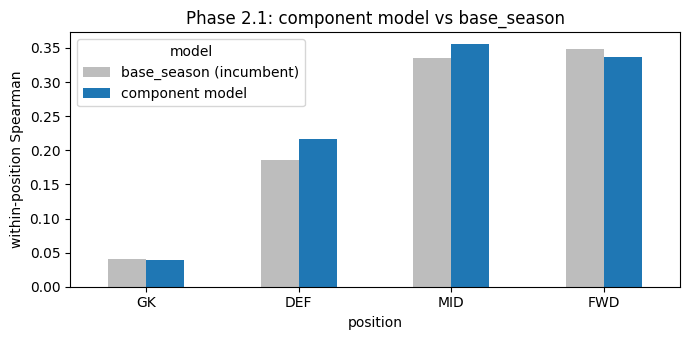

In [2]:
piv = comp.reset_index().pivot(index='position', columns='model', values='spearman').reindex(POSITIONS)
display(piv.round(4))
ax = piv.plot(kind='bar', figsize=(7,3.5), color=['#bdbdbd','#1f77b4'], rot=0)
ax.set_ylabel('within-position Spearman'); ax.set_title('Phase 2.1: component model vs base_season')
ax.axhline(0, color='k', lw=0.5); plt.tight_layout(); plt.show()

### Design check — is lagged xG a better predictor than lagged goals?

Before building the component model on process stats, confirm the input choice: rank players by their
strictly-prior expanding mean of `xg` vs of `goals_scored`, and see which better predicts next-GW
`goals_scored` (within position). xG winning justifies feeding the model lagged process stats over
lagged realized components.

In [ ]:
display(xg_goals.round(4))
print('xG wins every position -> use lagged process stats (xg/xa) as component-model features.')

## (b) Phase 2.2 — does a regularized combination beat BOTH bars? (closes A-F1)

Per-component elastic-net GLM over the full salvaged roster, gated against the incumbent **and** the
best single candidate signal. Clearing both means the roster earns its place, not just 'informative'.

model,base_season (incumbent),best single signal,regularized combination
position,,,
GK,0.0120,-0.1976,0.1182
DEF,0.1620,0.2166,0.2373
MID,0.3390,0.3683,0.3187
FWD,0.3208,0.3802,0.3313


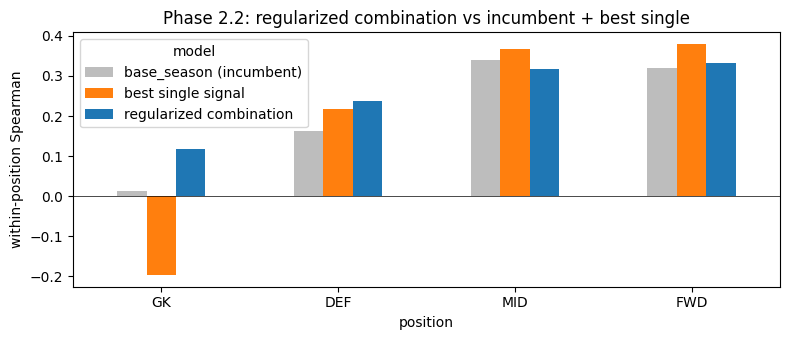

A-F1 gate = beat BOTH bars. Cleared only where the combination bar is highest.


In [3]:
order = ['base_season (incumbent)','best single signal','regularized combination']
pivc = combo.reset_index().pivot(index='position', columns='model', values='spearman').reindex(POSITIONS)[order]
display(pivc.round(4))
ax = pivc.plot(kind='bar', figsize=(8,3.5), color=['#bdbdbd','#ff7f0e','#1f77b4'], rot=0)
ax.set_ylabel('within-position Spearman'); ax.set_title('Phase 2.2: regularized combination vs incumbent + best single')
ax.axhline(0, color='k', lw=0.5); plt.tight_layout(); plt.show()
print('A-F1 gate = beat BOTH bars. Cleared only where the combination bar is highest.')

## (c) What did the penalty KEEP? (the A-F1 receipt)

`selection_stability` = share of walk-forward folds where each candidate's standardized coefficient is
non-zero. This is what demotes the family 'informative' labels to a prior — it shows what survived a
fair, tuned elastic-net selection.

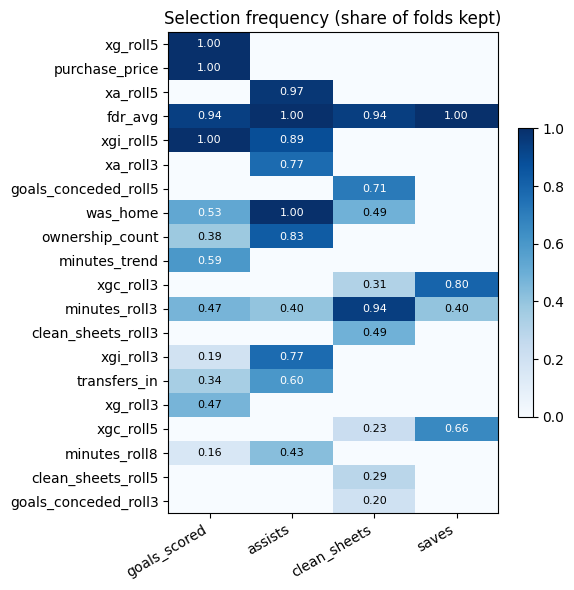

In [4]:
piv_sel = sel.reset_index().pivot(index='feature', columns='component', values='selection_freq')
piv_sel = piv_sel.reindex(columns=['goals_scored','assists','clean_sheets','saves'])
piv_sel = piv_sel.loc[piv_sel.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(piv_sel.fillna(-0.05).to_numpy(), cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(piv_sel.shape[1])); ax.set_xticklabels(piv_sel.columns, rotation=30, ha='right')
ax.set_yticks(range(piv_sel.shape[0])); ax.set_yticklabels(piv_sel.index)
for i in range(piv_sel.shape[0]):
    for j in range(piv_sel.shape[1]):
        v = piv_sel.iloc[i,j]
        if pd.notna(v): ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                                color='white' if v>0.5 else 'black')
ax.set_title('Selection frequency (share of folds kept)'); fig.colorbar(im, shrink=0.6); plt.tight_layout(); plt.show()

## Summary — Phase 2 verdict (what's proven / what's not)

**Proven:** situational features beat identity-only ranking at **DEF (+0.031)** and **MID (+0.019)**;
the regularized combination clears **both** A-F1 gates **only at DEF** (0.237 > 0.217 > 0.162). The
selection receipt shows `fdr_avg` kept across every component, **process `xg/xa_roll5` > roll3** (the xG-vs-goals check),
and `was_home` kept most for *assists* (overturning the v2 'defensive-only' placement).

**Not proven / honest limits:** **GK ~ chance and FWD behind incumbent** — goal-dominated FWD are
already ranked well by their scoring level; MID regresses under the *combination* vs a single
minutes-led signal. This is **ranking only** — whether it composes to a full points total is Phase 3,
and whether it helps a *decision* is Phase 5 (where, spoiler, a season-average is hard to beat).

*Bars Phase 3 builds on:* the DEF/MID component lift and the surviving signal set above.